In [29]:
import pandas as pd

In [30]:
df = pd.read_csv("sig_with_st.csv")

In [31]:
df.columns

Index(['PHQ_class', 'age_class', 'A2_gender', 'D1_daily_screen', 'A3_religion',
       'B1_residence', 'income_class', 'B4_family_type',
       'B5_time_with_parents_hours', 'B6_relationship_with_family',
       'weight_class', 'C3_physical_problems', 'D2_weekend_screen',
       'D3_device', 'D4_content', 'D5_parents_screen_time', 'D6_ai_daily',
       'D7_ai_impact', 'D8_creativity_decline', 'E1_sleep_duration',
       'E3_sleep_medicine', 'E5_bedtime', 'E6_wake_time',
       'F1_academic_satisfaction', 'F2_screen_impact', 'F3_learning_interest',
       'F4_interest_reduced', 'G1_mood_swings', 'G2_anxious_without_device',
       'G3_communication', 'G4_isolation', 'G5_negative_mental',
       'G6_panic_attack', 'H1_mobile_while_eating', 'H2_appetite_change',
       'BMI_class', 'D4_content_grouped'],
      dtype='str')

In [32]:

# Check target variable distribution
print("Target variable: D1_daily_screen")
print(df['D1_daily_screen'].value_counts())
print("\nShape:", df.shape)
print("\nMissing values:\n", df.isnull().sum().sum())


Target variable: D1_daily_screen
D1_daily_screen
1-3 hours            137
3-5 hours            125
Less than 1 hour     112
More than 5 hours     78
Name: count, dtype: int64

Shape: (452, 37)

Missing values:
 0


## Multinomial Logistic Regression — Target: `D1_daily_screen`

In [33]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [34]:
#  1. Prepare features and target
target = 'D1_daily_screen'
features = [c for c in df.columns if c != target]

X = df[features].copy()
y = df[target].copy()

# Encode every categorical column with a fresh LabelEncoder
encoders = {}
for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

le_target = LabelEncoder()
y_enc = le_target.fit_transform(y.astype(str))
class_names = le_target.classes_

print("Classes:", class_names)
print("Encoded labels:", np.unique(y_enc))


Classes: ['1-3 hours' '3-5 hours' 'Less than 1 hour' 'More than 5 hours']
Encoded labels: [0 1 2 3]


In [35]:

# 2. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")


Train size: 361  |  Test size: 91


In [36]:

# 3. Fit Multinomial Logistic Regression
mlr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
mlr.fit(X_train, y_train)
y_pred = mlr.predict(X_test)

# 4. Evaluation 
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


Test Accuracy: 0.4176 (41.76%)

Classification Report:
                   precision    recall  f1-score   support

        1-3 hours       0.33      0.39      0.36        28
        3-5 hours       0.43      0.48      0.45        25
 Less than 1 hour       0.58      0.50      0.54        22
More than 5 hours       0.36      0.25      0.30        16

         accuracy                           0.42        91
        macro avg       0.43      0.41      0.41        91
     weighted avg       0.42      0.42      0.42        91



### Odds Ratios (per class vs. reference)

In [ ]:

# Odds Ratios 
# OR = exp(coefficient); OR > 1 → increases odds of that class, < 1 → decreases
odds_ratio_df = pd.DataFrame(
    np.exp(mlr.coef_),
    index=class_names,
    columns=features
).T

print("Odds Ratios per class (rows=features, columns=D1_daily_screen classes):\n")
print(odds_ratio_df.round(4).to_string())


Odds Ratios per class (rows=features, columns=D1_daily_screen classes):

                             1-3 hours  3-5 hours  Less than 1 hour  More than 5 hours
PHQ_class                       1.1509     0.8978            1.0464             0.9249
age_class                       0.4978     1.2824            0.6804             2.3024
A2_gender                       0.7810     1.9949            0.5187             1.2375
A3_religion                     1.1294     0.7489            1.3847             0.8538
B1_residence                    0.4467     1.2563            0.8807             2.0234
income_class                    0.7298     0.9322            1.7043             0.8624
B4_family_type                  0.8572     0.9794            1.2244             0.9729
B5_time_with_parents_hours      0.8325     1.0665            0.8529             1.3207
B6_relationship_with_family     0.8267     0.7841            1.3148             1.1733
weight_class                    1.1326     0.7347        

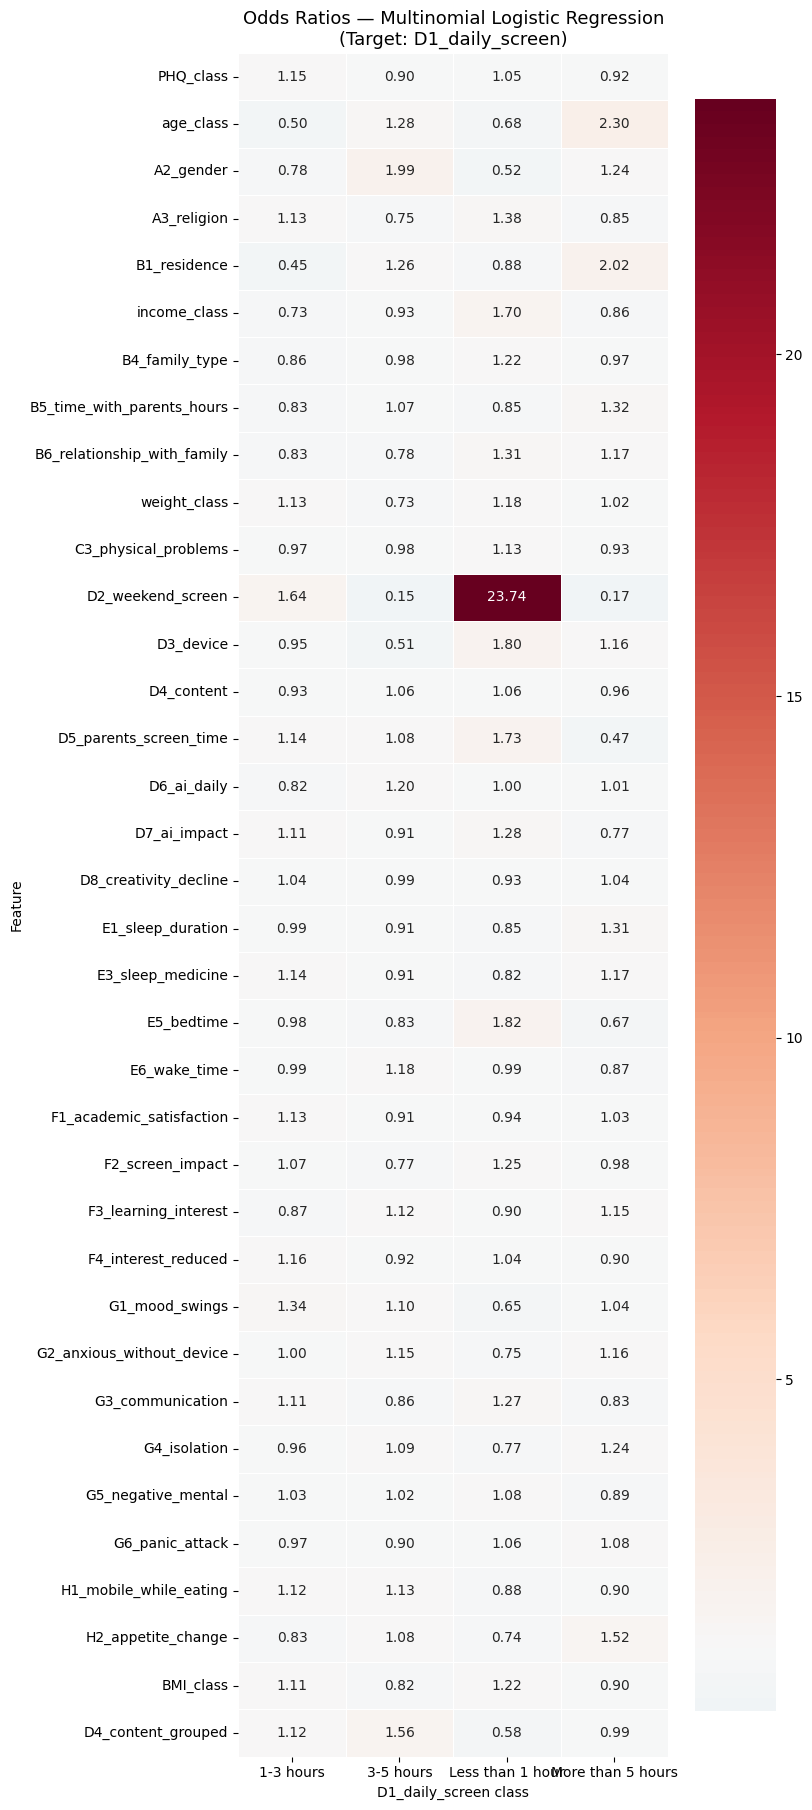

In [ ]:

# Odds Ratio Heatmap 
import seaborn as sns

fig, ax = plt.subplots(figsize=(max(8, len(class_names) * 2), len(features) * 0.45 + 2))
sns.heatmap(
    odds_ratio_df,
    annot=True, fmt=".2f",
    center=1.0,
    cmap="RdBu_r",
    linewidths=0.4,
    ax=ax
)
ax.set_title("Odds Ratios — Multinomial Logistic Regression\n(Target: D1_daily_screen)", fontsize=13)
ax.set_xlabel("D1_daily_screen class")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


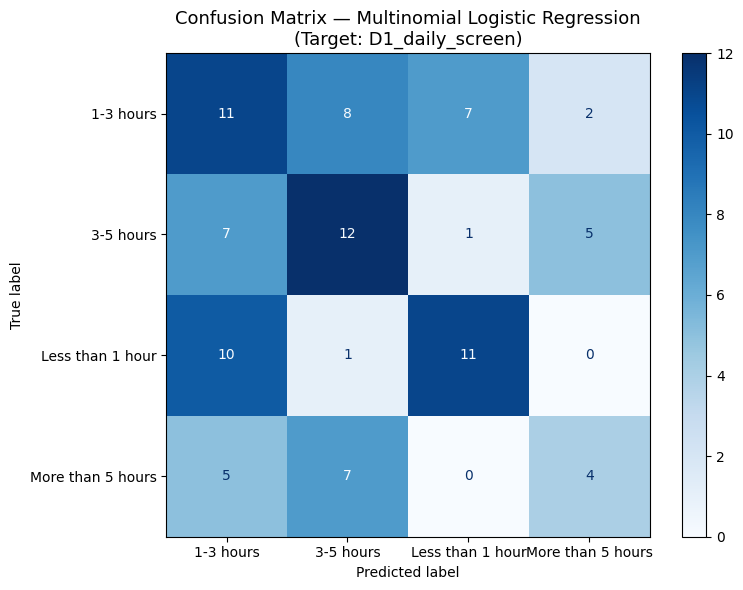

In [39]:

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title("Confusion Matrix — Multinomial Logistic Regression\n(Target: D1_daily_screen)", fontsize=13)
plt.tight_layout()
plt.show()


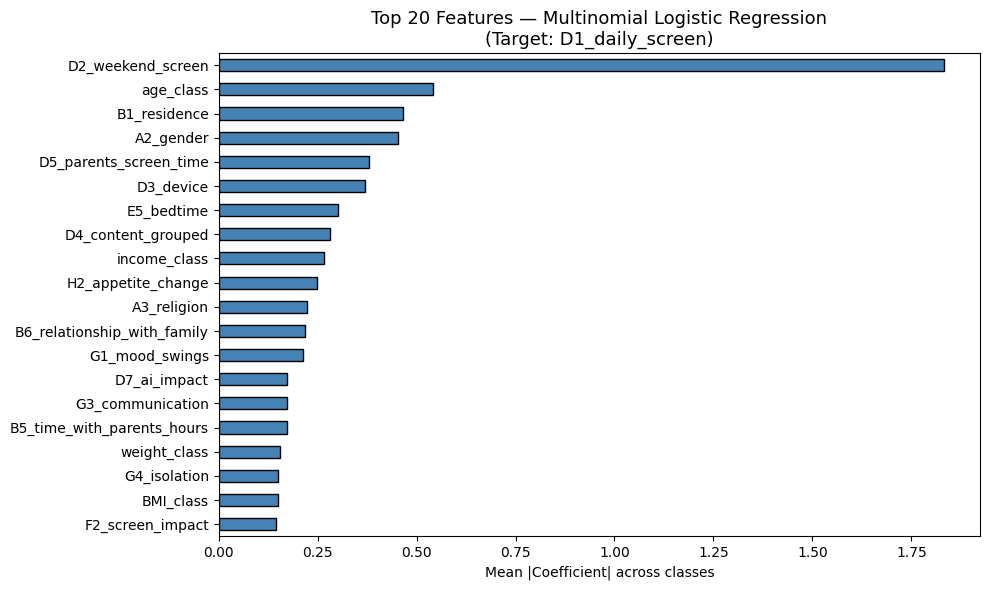


Top 15 features by mean absolute coefficient:
                             mean_abs
D2_weekend_screen            1.831912
age_class                    0.541345
B1_residence                 0.466465
A2_gender                    0.451858
D5_parents_screen_time       0.379846
D3_device                    0.368585
E5_bedtime                   0.300384
D4_content_grouped           0.281905
income_class                 0.266568
H2_appetite_change           0.247284
A3_religion                  0.223598
B6_relationship_with_family  0.216757
G1_mood_swings               0.213360
D7_ai_impact                 0.173382
G3_communication             0.172746
B5_time_with_parents_hours   0.171263
weight_class                 0.154124
G4_isolation                 0.150869
BMI_class                    0.150166
F2_screen_impact             0.144988


In [40]:

# 6. Feature Importance (Coefficients)
coef_df = pd.DataFrame(
    mlr.coef_,
    index=class_names,
    columns=features
).T

# Mean absolute coefficient across classes → overall importance
coef_df['mean_abs'] = coef_df.abs().mean(axis=1)
coef_df_sorted = coef_df.sort_values('mean_abs', ascending=False)

top_n = 20
fig, ax = plt.subplots(figsize=(10, 6))
coef_df_sorted['mean_abs'].head(top_n).sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='black'
)
ax.set_xlabel("Mean |Coefficient| across classes")
ax.set_title(f"Top {top_n} Features — Multinomial Logistic Regression\n(Target: D1_daily_screen)", fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop 15 features by mean absolute coefficient:")
print(coef_df_sorted[['mean_abs']].head(top_n).to_string())
